In [17]:
%pylab inline

import anacal
import numpy as np
import matplotlib.pylab as plt

import lsst.geom as geom
from numpy.lib import recfunctions as rfn
from astropy.visualization import simple_norm

from lsst.skymap.ringsSkyMap import (
    RingsSkyMap, RingsSkyMapConfig
)
from xlens.simulator.catalog import (
    CatalogShearTask,
    CatalogShearTaskConfig,
)
from xlens.simulator.sim import (
    MultibandSimConfig, MultibandSimTask
)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/home/xiangchong/miniconda3/envs/image/lib/python3.11/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['plt', 'det']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [18]:
config = RingsSkyMapConfig()
config.patchInnerDimensions = [501, 501]
config.tractOverlap = 0.0
config.patchBorder = 0        # pixels
config.numRings = 7000
config.pixelScale = 0.2
config.projection = "TAN"
skymap = RingsSkyMap(config=config)

config = CatalogShearTaskConfig()
config.extend_ratio = 0.92
config.kappa_value = 0.0000
config.test_value = 0.02
config.layout="grid"
config.test_target="g2"
cattask = CatalogShearTask(config=config)
truth = cattask.run(
    tract_info=skymap[0],
    seed=0,
).truthCatalog

In [19]:
config = MultibandSimConfig()
config.survey_name = (
    "lsst" 
)
config.force_isotropic=True
simtask = MultibandSimTask(config=config)
outcome = simtask.run(
    tract_info=skymap[0],
    patch_id=0,
    band="i",
    seed=0,
    truthCatalog=truth,
)

In [20]:
gal_array = np.asarray(
    outcome.simExposure.getMaskedImage().getImage().array,
    np.float64,
)
lsst_psf = outcome.simExposure.getPsf()
psf_array = np.asarray(
    anacal.utils.resize_array(
        lsst_psf.computeImage(
            geom.Point2D(250, 250)
        ).getArray(), (64, 64)
    ),
    dtype=np.float64,
)

Text(0.5, 1.0, 'PSF')

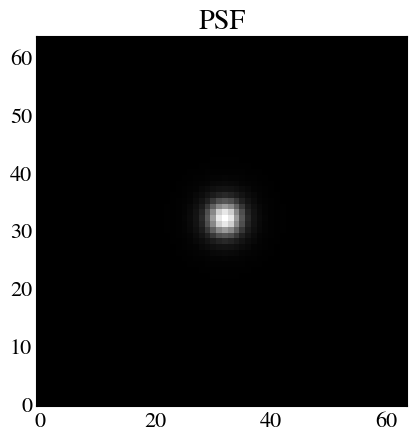

In [21]:
plt.close()
# Display the PSF image simulation
plt.imshow(psf_array, cmap="Greys_r", origin="lower")
plt.title("PSF")

# FPFS

In [22]:
noise_variance = 0.24
fpfs_c0 = 8.4
mag_zero = 30.0
pixel_scale = 0.2

fpfs_peaks_dtype = np.dtype([("y", np.float64), ("x", np.float64)])
det = np.zeros(len(truth), dtype=fpfs_peaks_dtype)
wcs = skymap[0].getWcs()
det["x"], det["y"] = wcs.skyToPixelArray(truth["ra"], truth["dec"], degrees=True)

fpfs_config = anacal.fpfs.FpfsConfig(
    sigma_shapelets1=0.52,
)
out = anacal.fpfs.process_image(
    fpfs_config=fpfs_config,
    pixel_scale=pixel_scale,
    mag_zero=mag_zero,
    noise_variance=noise_variance,
    gal_array=gal_array,
    psf_array=psf_array,  
    mask_array=None,
    noise_array=None,
    detection=det,
    do_compute_detect_weight=False,
)

Text(0.5, 1.0, 'Exposure')

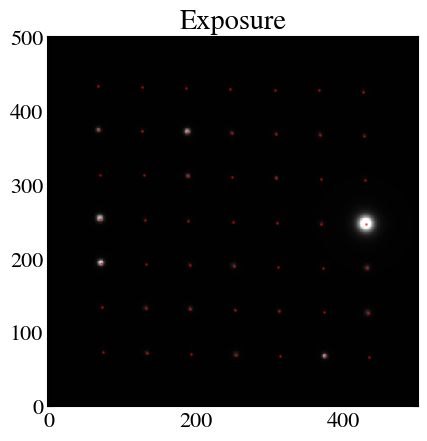

In [23]:
plt.scatter(det["x"], det["y"], marker="o", alpha=0.5, s=1.0, color="red")
plt.imshow(
    gal_array,
    aspect="equal",
    cmap="Greys_r",
    origin="lower",
    interpolation="None",
    norm=simple_norm(gal_array, "asinh", asinh_a=0.2, min_cut=-0.1, max_cut=30),
)
plt.title("Exposure")

In [24]:
assert np.abs(np.sum(out["fpfs1_e1"]) / np.sum(out["fpfs1_de1_dg1"])) < 1e-4

In [25]:
assert np.abs((np.sum(out["fpfs1_e2"]) / np.sum(out["fpfs1_de2_dg2"]) + 0.02) / 0.02) < 0.003

# Forced measurement with processor subtasks

Use ``AnacalTask`` and ``FpfsMeasurementTask`` (the subtasks inside
``MeasureCoaddsPipe``) with an external detection catalog built from
truth positions via ``anacal.table.make_catalog_empty``.

# Forced measurement with MeasureCoaddsPipe

Use ``MeasureCoaddsPipe.run()`` with an external detection catalog built
from truth positions via ``anacal.table.make_catalog_empty``.

In [26]:
from lsst.daf.butler import DataCoordinate, DimensionUniverse
from xlens.processor.measure_coadds import (
    MeasureCoaddsPipeConfig,
    MeasureCoaddsPipe,
)

In [27]:
# Build external detection catalog in galRow format.
# anacal.table.make_catalog_empty expects x1, x2 in arcsec.
wcs = skymap[0].getWcs()
pixel_scale = 0.2
px, py = wcs.skyToPixelArray(truth["ra"], truth["dec"], degrees=True)
x1_arcsec = px * pixel_scale
x2_arcsec = py * pixel_scale

detection = anacal.table.make_catalog_empty(x1_arcsec, x2_arcsec)
print(f"Detection catalog: {len(detection)} sources")

Detection catalog: 49 sources


In [28]:
# Build a proper exposure handle dict for MeasureCoaddsPipe.run().
# The handle must provide .get() -> Exposure and .dataId -> DataCoordinate.
universe = DimensionUniverse()
skymap_element = universe["skymap"]
skymap_record = skymap_element.RecordClass(
    name="test", hash=b"0" * 32,
    tract_max=100, patch_nx_max=100, patch_ny_max=100,
)
data_id = DataCoordinate.standardize(
    {"skymap": "test", "tract": 0, "patch": 0, "band": "i"},
    universe=universe,
).expanded({skymap_element: skymap_record})


class ExposureHandle:
    """Minimal wrapper mimicking a DeferredDatasetHandle."""
    def __init__(self, exposure, data_id):
        self._exp = exposure
        self.dataId = data_id

    def get(self):
        return self._exp


exposure_handles_dict = {"i": ExposureHandle(outcome.simExposure, data_id)}

In [29]:
# Configure and run the pipeline.
# Disable noise bias correction since the simulation is noiseless.
pipe_config = MeasureCoaddsPipeConfig()
pipe_config.anacal.force_size = True
pipe_config.anacal.force_center = True
pipe_config.anacal.do_noise_bias_correction = False
pipe_config.fpfs.do_compute_detect_weight = False
pipe_config.fpfs.sigma_shapelets1 = 0.52
pipe_config.fpfs.do_noise_bias_correction = False

pipe = MeasureCoaddsPipe(config=pipe_config)

result = pipe.run(
    exposure_handles_dict=exposure_handles_dict,
    corr_array=None,
    skyMap=skymap,
    tract=0,
    patch=0,
    detection=detection,
)
cat = result.output_catalog
print(f"Output catalog: {len(cat)} sources")

Output catalog: 49 sources


In [30]:
print("Output columns:")
print(cat.dtype.names)

Output columns:
('ra', 'dec', 'flux', 'dflux_dg1', 'dflux_dg2', 'dflux_dj1', 'dflux_dj2', 't', 'dt_dg1', 'dt_dg2', 'dt_dj1', 'dt_dj2', 'a1', 'da1_dg1', 'da1_dg2', 'da1_dj1', 'da1_dj2', 'a2', 'da2_dg1', 'da2_dg2', 'da2_dj1', 'da2_dj2', 'e1', 'de1_dg1', 'de1_dg2', 'de1_dj1', 'de1_dj2', 'e2', 'de2_dg1', 'de2_dg2', 'de2_dj1', 'de2_dj2', 'x1', 'dx1_dg1', 'dx1_dg2', 'dx1_dj1', 'dx1_dj2', 'x2', 'dx2_dg1', 'dx2_dg2', 'dx2_dj1', 'dx2_dj2', 'wdet', 'dwdet_dg1', 'dwdet_dg2', 'dwdet_dj1', 'dwdet_dj2', 'wsel', 'dwsel_dg1', 'dwsel_dg2', 'dwsel_dj1', 'dwsel_dj2', 'mask_value', 'is_peak', 'is_primary', 'flux_gauss0', 'dflux_gauss0_dg1', 'dflux_gauss0_dg2', 'dflux_gauss0_dj1', 'dflux_gauss0_dj2', 'flux_gauss2', 'dflux_gauss2_dg1', 'dflux_gauss2_dg2', 'dflux_gauss2_dj1', 'dflux_gauss2_dj2', 'flux_gauss4', 'dflux_gauss4_dg1', 'dflux_gauss4_dg2', 'dflux_gauss4_dj1', 'dflux_gauss4_dj2', 'flux_gauss0_err', 'flux_gauss2_err', 'flux_gauss4_err', 'fpfs_e1', 'fpfs_de1_dg1', 'fpfs_de1_dg2', 'fpfs_de1_dj1', 'fpfs

In [31]:
# Check shear recovery from the FPFS fields in the pipeline output.
# Fields are prefixed with band name "i_".
prefix = "i_fpfs1_"
g1_pipe = np.sum(cat[f"{prefix}e1"]) / np.sum(cat[f"{prefix}de1_dg1"])
g2_pipe = np.sum(cat[f"{prefix}e2"]) / np.sum(cat[f"{prefix}de2_dg2"])
print(f"g1 = {g1_pipe:.6f} (expected ~0)")
print(f"g2 = {g2_pipe:.6f} (expected ~-0.02)")

assert np.abs(g1_pipe) < 1e-4
assert np.abs((g2_pipe + 0.02) / 0.02) < 0.003
print("MeasureCoaddsPipe shear recovery passed!")

g1 = -0.000044 (expected ~0)
g2 = -0.020003 (expected ~-0.02)
MeasureCoaddsPipe shear recovery passed!
